In [1]:
# Installation des bibliothèques nécessaires et chemin d'accès aux modules
import pandas as pd
import numpy as np
import sys
sys.path.append('..')  # Pour que Python trouve le dossier src/
from src.utils import overview, reduce_memory, clean_application


In [2]:
# Lecture du jeu de données d'entraînement
train = pd.read_csv("../data/raw/application_train.csv")
overview(train, "application_train.csv")


  application_train.csv
  Shape : 307511 lignes x 122 colonnes
  Mémoire : 562.8 Mo
  Doublons : 0
  Valeurs manquantes : 64 colonnes
                              missing_pct    dtype
COMMONAREA_MEDI                      69.9  float64
COMMONAREA_AVG                       69.9  float64
COMMONAREA_MODE                      69.9  float64
NONLIVINGAPARTMENTS_MODE             69.4  float64
NONLIVINGAPARTMENTS_AVG              69.4  float64
NONLIVINGAPARTMENTS_MEDI             69.4  float64
LIVINGAPARTMENTS_MODE                68.4  float64
LIVINGAPARTMENTS_AVG                 68.4  float64
FONDKAPREMONT_MODE                   68.4      str
LIVINGAPARTMENTS_MEDI                68.4  float64
FLOORSMIN_AVG                        67.8  float64
FLOORSMIN_MODE                       67.8  float64
FLOORSMIN_MEDI                       67.8  float64
YEARS_BUILD_MEDI                     66.5  float64
YEARS_BUILD_MODE                     66.5  float64
YEARS_BUILD_AVG                      66.5  float6

,missing_pct,dtype
COMMONAREA_MEDI,69.9,float64
COMMONAREA_AVG,69.9,float64
COMMONAREA_MODE,69.9,float64
NONLIVINGAPARTMENTS_MODE,69.4,float64
NONLIVINGAPARTMENTS_AVG,69.4,float64
...,...,...
OBS_30_CNT_SOCIAL_CIRCLE,0.3,float64
OBS_60_CNT_SOCIAL_CIRCLE,0.3,float64
DEF_60_CNT_SOCIAL_CIRCLE,0.3,float64
EXT_SOURCE_2,0.2,float64


In [3]:
# Distribution de la variable cible
train['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

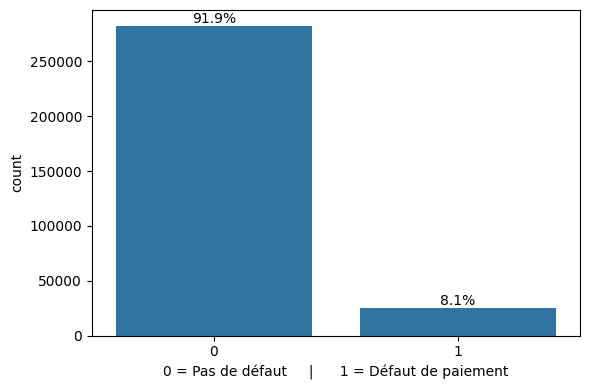

In [4]:
# graphique de distribution de la variable cible
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize = (6, 4))
sns.countplot(x = 'TARGET', data = train, ax=ax)

for p in ax.patches :
    pct = p.get_height() / len(train) * 100
    ax.annotate(f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom')

ax.set_tittle = ("distribution de la TARGET")
ax.set_xlabel('0 = Pas de défaut     |      1 = Défaut de paiement')
plt.tight_layout()
plt.show()

Le dataset est fortement déséquilibré : 92% de classe 0 contre 8% de classe 1. Ce déséquilibre devra être pris en compte lors de la modélisation.

### VARIABLES NUMERIQUES

In [5]:
# Corrélation entre les variables numériques et la TARGET
correlation = train.corr(numeric_only=True)["TARGET"].sort_values(ascending=False)
print("TOP 10 corrélation positives")
print(correlation.head(10))
print("\nTOP 10 corrélation negatives")
print(correlation.tail(10))

TOP 10 corrélation positives
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64

TOP 10 corrélation negatives
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


- Les `EXT_SOURCE` dominent clairement, elles sont de loin devant tout le reste. 
La corrélation est négative, ce qui signifie que plus le score externe est élevé, moins le client fait défaut.
- Les corrélations sont globalement faibles. La deuxieme meilleur variable c'est `DAY_EMPLOYED` à -0,045. C'est trés bas. Cela veut dire qu'aucune variable seule ne suffit à prédire le défaut, Il faudra la combinaison de plusieurs features.

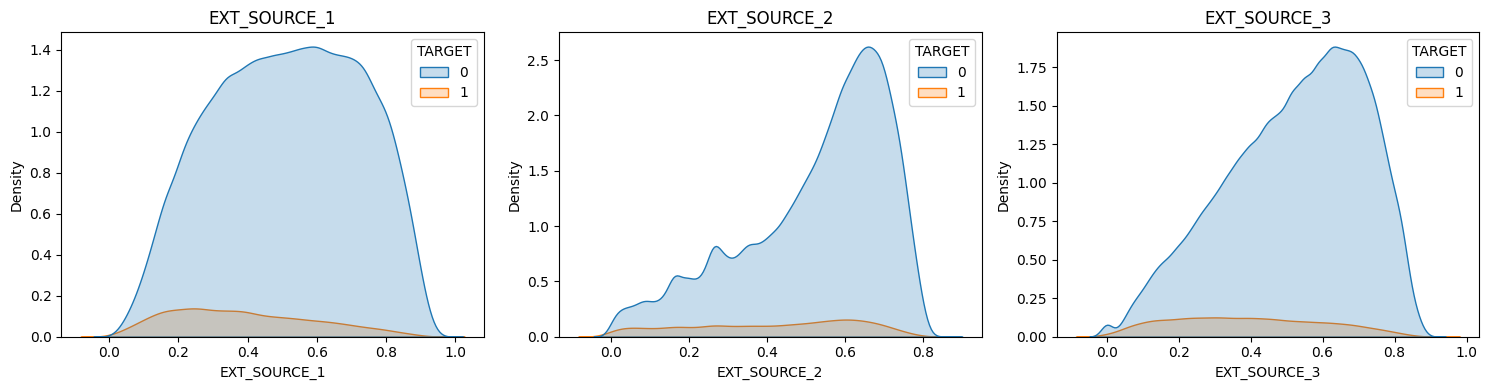

In [6]:
# Kdplot de nos variables les plus corrélées EXT_SOURCE 1,2,3 avec la TARGET

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=train, x=col, hue='TARGET', ax=axes[i], fill=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

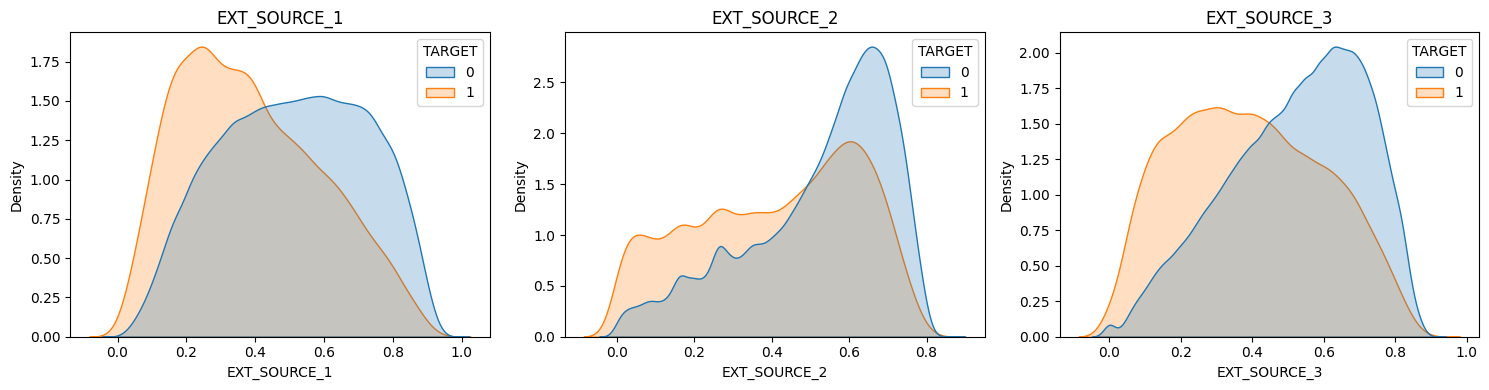

In [7]:
# Kdplot de nos variables normalisées plus corrélées EXT_SOURCE 1,2,3 avec la TARGET

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=train, x=col, hue='TARGET', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

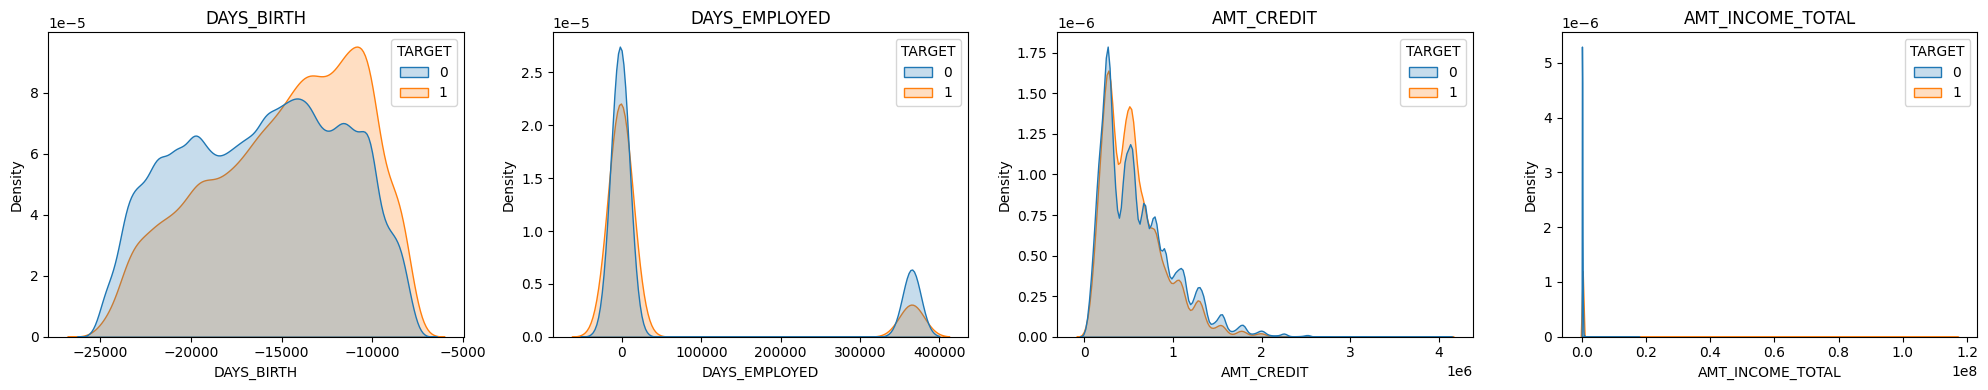

In [8]:
# Kdplot de nos variables les plus corrélées avec la TARGET (DAYS_BIRTH, DAYS_EMPLOYED, AMT_CREDIT, AMT_INCOME_TOTAL)
fig, axes = plt.subplots(1,4, figsize=(20,4))
for i, col in enumerate(['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_INCOME_TOTAL']):
    sns.kdeplot(data=train, x=col, hue='TARGET', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

- `DAY_BIRTH`: Les clients plus jeunes font plus souvent défaut
- `DAY_EMPLOYED`: On retrouve un pic isolé autour de 370 000 soit environ 1000 ans, c'est évidemment impossible, nous sommes face à des valeurs aberrantes.

In [9]:
# Analyse des valeurs extrêmes de DAYS_EMPLOYED
train[train['DAYS_EMPLOYED'] > 300000]['DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64

In [10]:
train['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

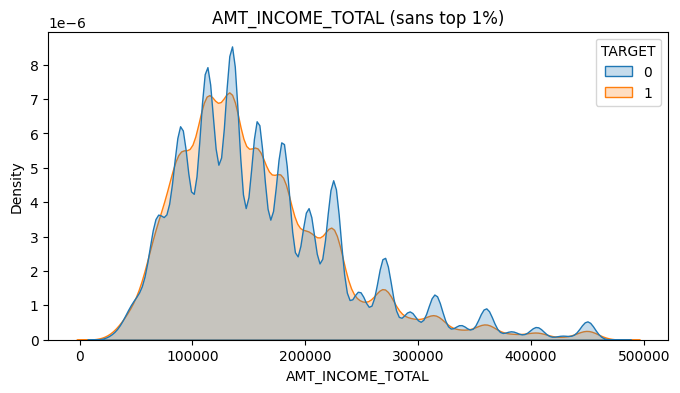

In [11]:
# Visualiser sans les extrêmes (99e percentile)
seuil = train['AMT_INCOME_TOTAL'].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=train[train['AMT_INCOME_TOTAL'] < seuil], 
            x='AMT_INCOME_TOTAL', hue='TARGET', fill=True, common_norm=False, ax=ax)
ax.set_title('AMT_INCOME_TOTAL (sans top 1%)')
plt.show()

In [12]:
# Description des variables numériques pour identifier les valeurs extrêmes
train.describe().T.sort_values(by='max', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
OBS_30_CNT_SOCIAL_CIRCLE,306490.0,1.422245,2.400989,0.0,0.0,0.0,2.0,348.0
OBS_60_CNT_SOCIAL_CIRCLE,306490.0,1.405292,2.379803,0.0,0.0,0.0,2.0,344.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
OWN_CAR_AGE,104582.0,12.061091,11.944812,0.0,5.0,9.0,15.0,91.0


- `DAYS_EMPLOYED`On le confirme le max à 365 243 alors que tout le reste sont des valeurs négatifs (min à -17 912). 
- `AMT_INCOME_TOTAL` Max à 117 000 000, médiane à 147 150. On se penchera sur ses valeurs extremes pour détérminer si oui ou non elles sont aberrantes.
- `OBS_30_CNT_SOCIAL_CIRCLE` Moyenne à 1.4, mais max à 348 cela semble extrême. Pareil pour `OBS_60_CNT_SOCIAL_CIRCLE`à 344
- `AMT_REQ_CREDIT_BUREAU_QRT` Moyenne à 0,27 mais max à 261 demandes au bureau de crédit en un trimestre ...
- `CNT_CHILDREN` Max à 19 enfants. Possible mais très rare, on verifiera combien de clients sont dans ce cas.

In [13]:
# Valeurs extrêmes d'enfants 
train['CNT_CHILDREN'].value_counts().tail(10)

CNT_CHILDREN
5     84
6     21
7      7
14     3
8      2
9      2
12     2
10     2
19     2
11     1
Name: count, dtype: int64

In [14]:
# Combien de clients ont des revenus extrêmes ?
seuils = [1_000_000, 5_000_000, 10_000_000, 50_000_000]
for s in seuils:
    n = len(train[train['AMT_INCOME_TOTAL'] > s])
    print(f"Revenus > {s:>12,} : {n} clients")

# Regarder les plus gros revenus
train.nlargest(10, 'AMT_INCOME_TOTAL')[['SK_ID_CURR', 'AMT_INCOME_TOTAL', 
                                         'AMT_CREDIT', 'NAME_INCOME_TYPE',
                                         'OCCUPATION_TYPE']]

Revenus >    1,000,000 : 250 clients
Revenus >    5,000,000 : 5 clients
Revenus >   10,000,000 : 3 clients
Revenus >   50,000,000 : 1 clients


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_INCOME_TYPE,OCCUPATION_TYPE
12840,114967,117000000.0,562491.0,Working,Laborers
203693,336147,18000090.0,675000.0,Commercial associate,NaN
246858,385674,13500000.0,1400503.5,Commercial associate,NaN
77768,190160,9000000.0,1431531.0,Working,Managers
131127,252084,6750000.0,790830.0,Working,Laborers
103006,219563,4500000.0,2250000.0,Working,Managers
187833,317748,4500000.0,835380.0,Working,Laborers
204564,337151,4500000.0,450000.0,Working,Managers
287463,432980,4500000.0,1755000.0,Working,Managers
181698,310601,3950059.5,675000.0,Commercial associate,Managers


`AMT_INCOME_TOTAL` 
- 250 clients > 1M (0.01% du dataset)
- 8 clients ≥ 5M 
- Le max à 117M est un "Ouvrier" c'est incohérent
 

### VARIABLES CATEGORIELLES

In [15]:
# Identifier toutes les variables catégorielles
cat_all = train.select_dtypes(include='object').columns.tolist()
print(f"Nombre de variables catégorielles : {len(cat_all)}")
for col in cat_all:
    print(f"  {col} : {train[col].nunique()} modalités")

Nombre de variables catégorielles : 16
  NAME_CONTRACT_TYPE : 2 modalités
  CODE_GENDER : 3 modalités
  FLAG_OWN_CAR : 2 modalités
  FLAG_OWN_REALTY : 2 modalités
  NAME_TYPE_SUITE : 7 modalités
  NAME_INCOME_TYPE : 8 modalités
  NAME_EDUCATION_TYPE : 5 modalités
  NAME_FAMILY_STATUS : 6 modalités
  NAME_HOUSING_TYPE : 6 modalités
  OCCUPATION_TYPE : 18 modalités
  WEEKDAY_APPR_PROCESS_START : 7 modalités
  ORGANIZATION_TYPE : 58 modalités
  FONDKAPREMONT_MODE : 4 modalités
  HOUSETYPE_MODE : 3 modalités
  WALLSMATERIAL_MODE : 7 modalités
  EMERGENCYSTATE_MODE : 2 modalités


/var/folders/m5/mkh7m3r5249c4p2tn8rz71100000gn/T/ipykernel_67616/3585520329.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_all = train.select_dtypes(include='object').columns.tolist()


## Variables catégorielles
X variables catégorielles identifiées. 
On se concentre sur celles liées au profil du client :
- Situation financière : NAME_INCOME_TYPE
- Éducation : NAME_EDUCATION_TYPE
- Situation familiale : NAME_FAMILY_STATUS
- Logement : NAME_HOUSING_TYPE
- Genre : CODE_GENDER
- Métier : OCCUPATION_TYPE

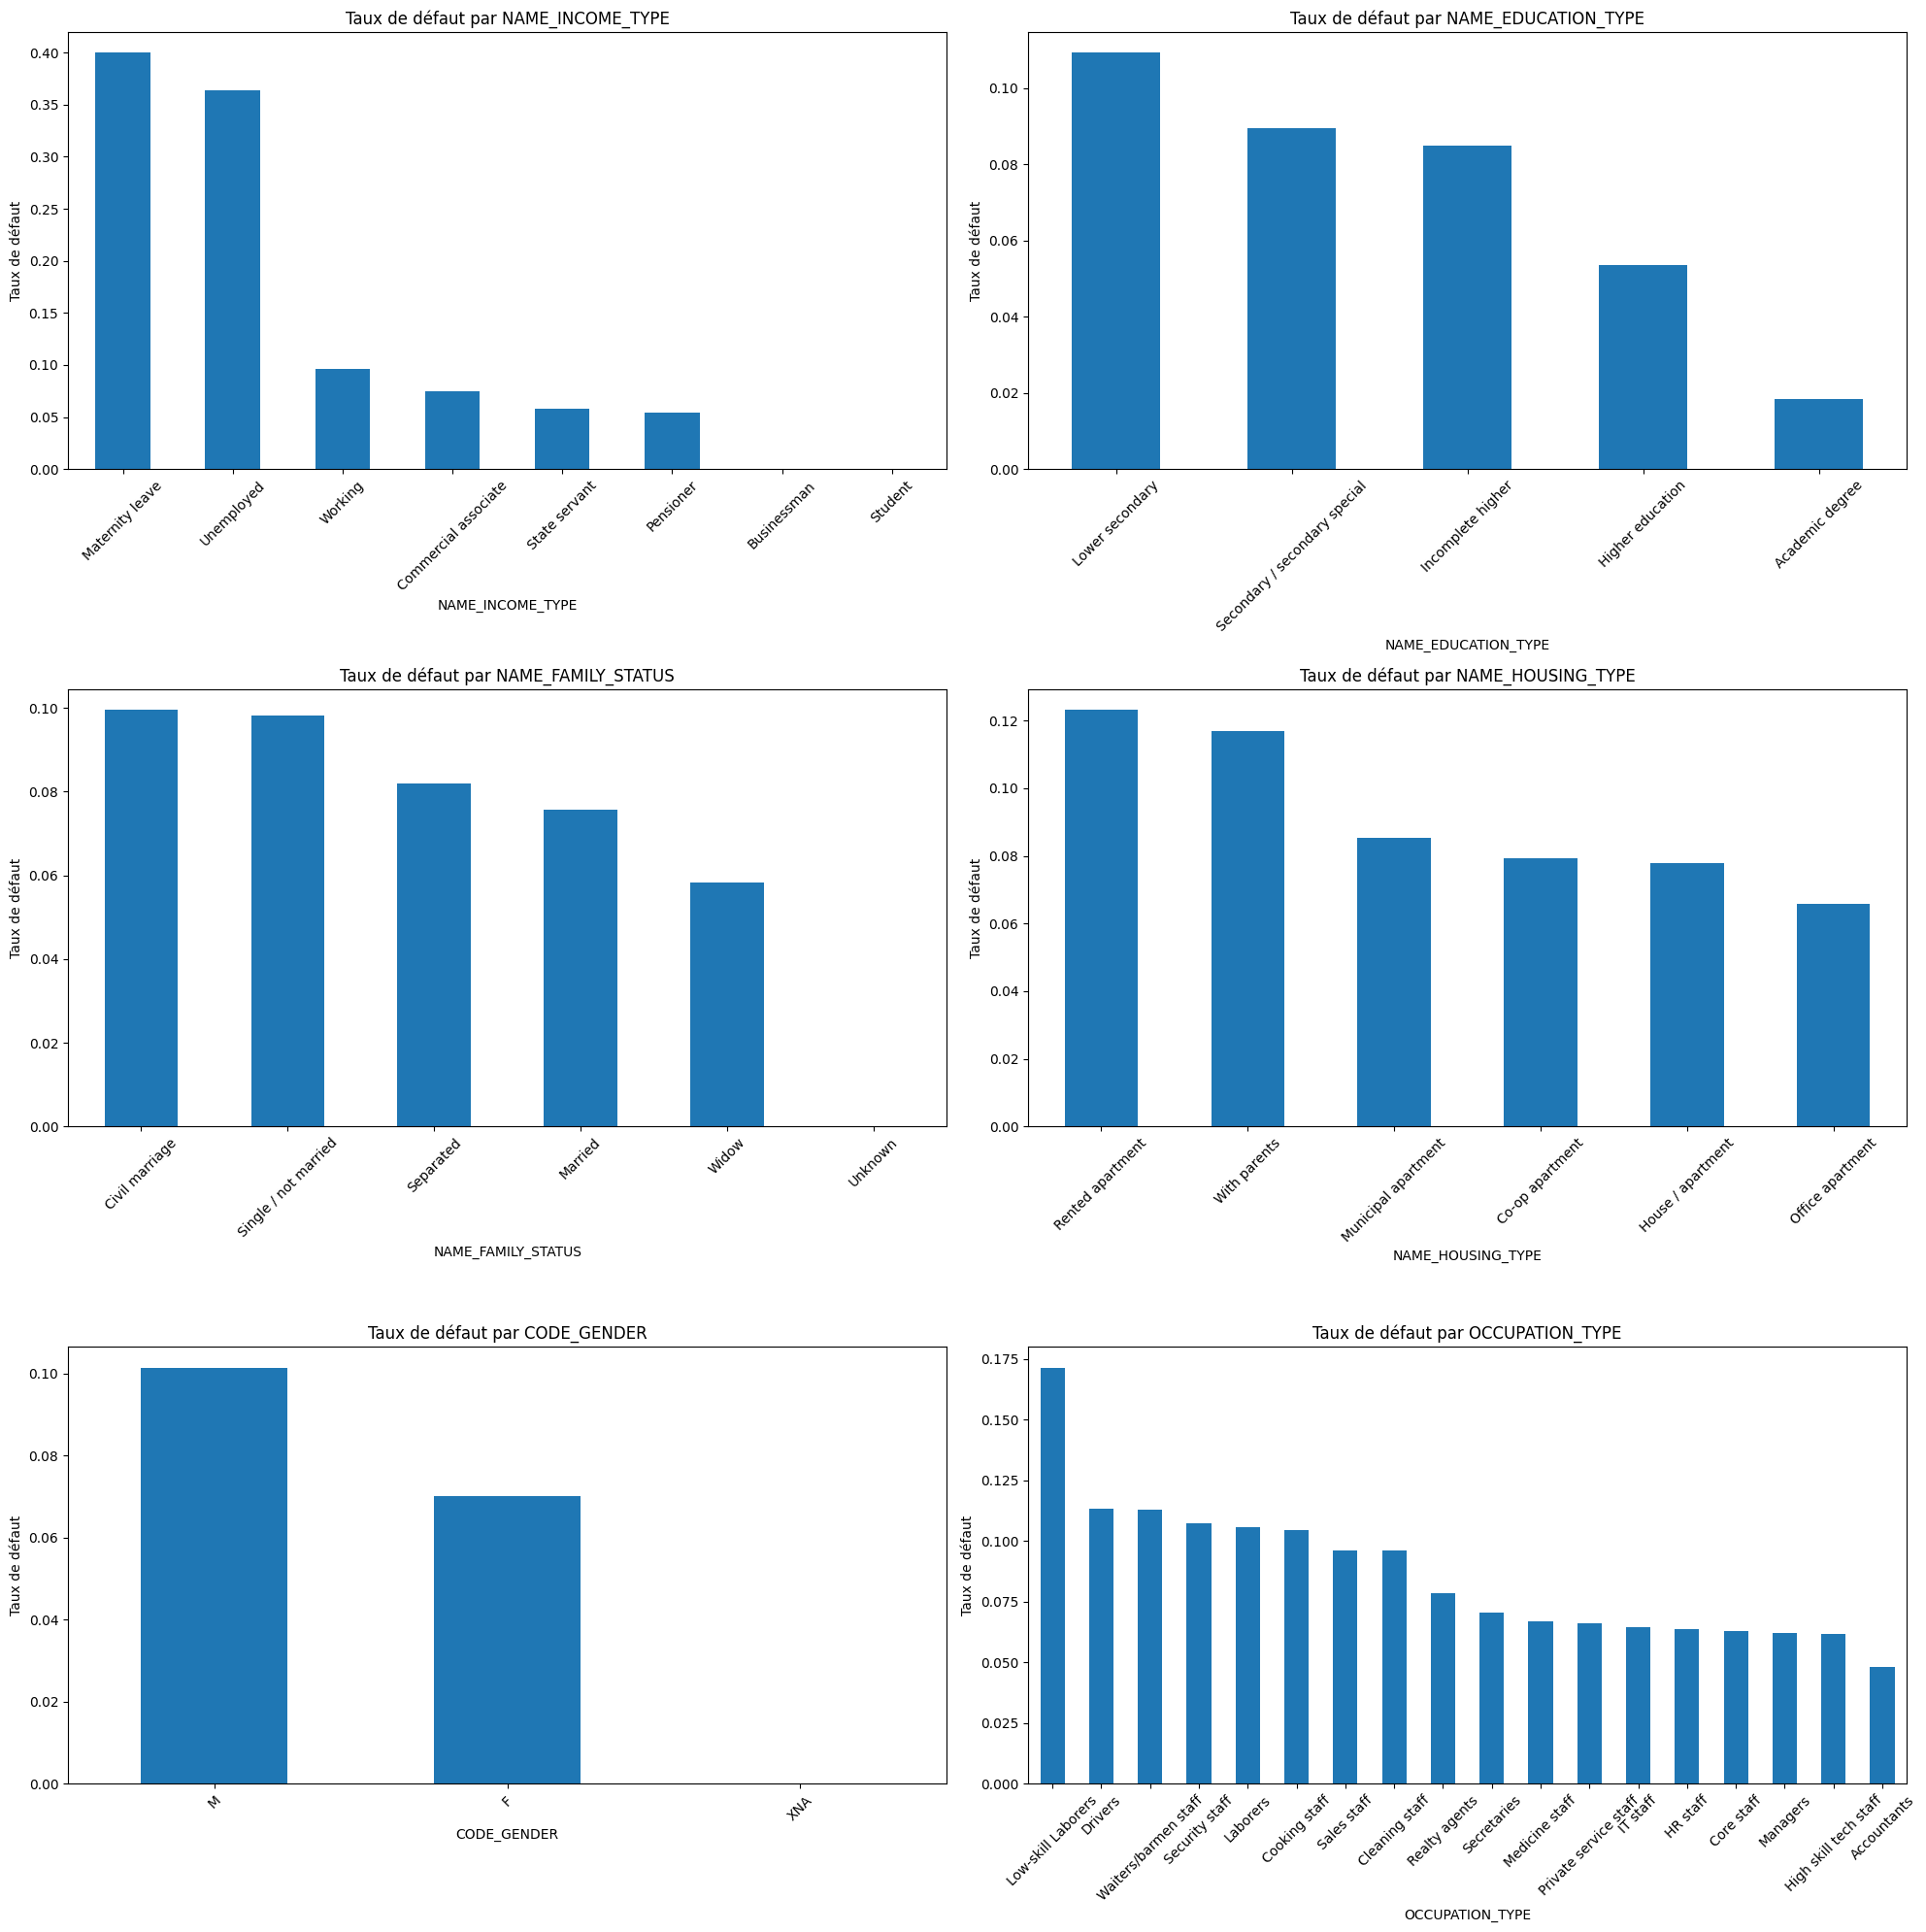

In [16]:
# Taux de défaut par catégorie pour les variables catégorielles les plus importantes
cat_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 
            'NAME_HOUSING_TYPE', 'CODE_GENDER', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rates = train.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Taux de défaut par {col}')
    axes[i].set_ylabel('Taux de défaut')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Analyse de la répartition NAME_INCOME_TYPE
train['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [18]:
# Analyse de la répartition Homme/Femme
train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [19]:
# Analyse de la répartition NAME_FAMILY_STATUS
train['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [20]:
train['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

- Maternity leave (5 clients) et Unemployed (22 clients) : taux de défaut très élevés 
  mais effectifs trop faibles pour être significatifs
- Les catégories fiables : Working (158K), Commercial associate (71K), 
  Pensioner (55K), State servant (21K)
- Parmi celles-ci, Working (~10%) est la plus risquée, Pensioner (~5%) la moins
- Pour code_ gender 4 clients avec "XNA", c'est une anomalie je pense même chose pour name_family_status avec 2 clients inconnue.

In [21]:


for col in ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']:
    print(f"\n{col}:")
    print(train.groupby(col)['TARGET'].agg(['mean', 'count']))


NAME_CONTRACT_TYPE:
                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083459  278232
Revolving loans     0.054783   29279

FLAG_OWN_CAR:
                  mean   count
FLAG_OWN_CAR                  
N             0.085002  202924
Y             0.072437  104587

FLAG_OWN_REALTY:
                     mean   count
FLAG_OWN_REALTY                  
N                0.083249   94199
Y                0.079616  213312

EMERGENCYSTATE_MODE:
                         mean   count
EMERGENCYSTATE_MODE                  
No                   0.069649  159428
Yes                  0.095790    2328


In [22]:
# Analyser les variables FLAG_DOCUMENT
flag_docs = [col for col in train.columns if col.startswith('FLAG_DOCUMENT')]
for col in flag_docs:
    pct_one = train[col].mean() * 100
    if pct_one > 1:  # On ne regarde que ceux qui ont plus de 1% de "1"
        target_rate = train[train[col]==1]['TARGET'].mean()
        print(f"  {col}: {pct_one:.1f}% fourni, taux défaut = {target_rate:.3f}")

  FLAG_DOCUMENT_3: 71.0% fourni, taux défaut = 0.088
  FLAG_DOCUMENT_5: 1.5% fourni, taux défaut = 0.080
  FLAG_DOCUMENT_6: 8.8% fourni, taux défaut = 0.056
  FLAG_DOCUMENT_8: 8.1% fourni, taux défaut = 0.073


In [23]:
# Analyse du percentile 99 et du max de AMT_REQ_CREDIT_BUREAU_QRT

for col in ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
            'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']:
    print(f"\n{col}:")
    print(f"  99e percentile : {train[col].quantile(0.99)}")
    print(f"  max : {train[col].max()}")


OBS_30_CNT_SOCIAL_CIRCLE:
  99e percentile : 10.0
  max : 348.0

DEF_30_CNT_SOCIAL_CIRCLE:
  99e percentile : 2.0
  max : 34.0

OBS_60_CNT_SOCIAL_CIRCLE:
  99e percentile : 10.0
  max : 344.0

DEF_60_CNT_SOCIAL_CIRCLE:
  99e percentile : 2.0
  max : 24.0


In [24]:
# Analyser les valeurs extremes de AMT_REQ_CREDIT_BUREAU_QRT
print(f"QRT 99e : {train['AMT_REQ_CREDIT_BUREAU_QRT'].quantile(0.99)}")
print(f"QRT 95e : {train['AMT_REQ_CREDIT_BUREAU_QRT'].quantile(0.95)}")

QRT 99e : 2.0
QRT 95e : 2.0


In [25]:
# Combien de clients ont plus de 5 ou 10 demandes de crédit ?
print(train['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts().head(10))
print(f"\n> 5 : {len(train[train['AMT_REQ_CREDIT_BUREAU_QRT'] > 5])} clients")
print(f"> 10 : {len(train[train['AMT_REQ_CREDIT_BUREAU_QRT'] > 10])} clients")

AMT_REQ_CREDIT_BUREAU_QRT
0.0      215417
1.0       33862
2.0       14412
3.0        1717
4.0         476
5.0          64
6.0          28
8.0           7
7.0           7
261.0         1
Name: count, dtype: int64

> 5 : 44 clients
> 10 : 2 clients


In [26]:
# Analyser les variables OBS_30_CNT_SOCIAL_CIRCLE > 50 et > 100 
print(f"\nSOCIAL_CIRCLE > 50 : {len(train[train['OBS_30_CNT_SOCIAL_CIRCLE'] > 50])} clients")
print(f"SOCIAL_CIRCLE > 100 : {len(train[train['OBS_30_CNT_SOCIAL_CIRCLE'] > 100])} clients")


SOCIAL_CIRCLE > 50 : 1 clients
SOCIAL_CIRCLE > 100 : 1 clients


##### Bilan — Décisions de nettoyage

###### Valeurs aberrantes / incohérentes
1. DAYS_EMPLOYED : 365243 -> remplacer par NaN
2. CODE_GENDER : 4 "XNA" -> supprimer les lignes
3. NAME_FAMILY_STATUS : 2 "Unknown" -> supprimer les lignes
4. AMT_INCOME_TOTAL : quelques valeurs extrêmes (max 117M) -> outliers à capper
5. OBS_30/60_CNT_SOCIAL_CIRCLE : max 348/344 -> outliers à capper
6. AMT_REQ_CREDIT_BUREAU_QRT : max 261 -> outlier à capper

###### Valeurs manquantes
- Bloc logement (~45 colonnes) : 50-70% de NaN -> garder tel quel, ou remplacer par la mediane selon le modèle utilisé
- OCCUPATION_TYPE : 31% NaN -> garder tel quel, ou remplacer par la mediane selon le modèle utilisé
- EXT_SOURCE_1 : 56% NaN -> garder tel quel, ou remplacer par la mediane selon le modèle utilisé

###### Catégorielles à faible effectif
- NAME_INCOME_TYPE : Maternity leave (5), Businessman (10), Student (18) -> regrouper en "Other" ou garder   

In [27]:
# Charger le jeu de données de test et faire un aperçu rapide
test = pd.read_csv("../data/raw/application_test.csv")
overview(test, "application_test.csv")


  application_test.csv
  Shape : 48744 lignes x 121 colonnes
  Mémoire : 88.9 Mo
  Doublons : 0
  Valeurs manquantes : 62 colonnes
                              missing_pct    dtype
COMMONAREA_AVG                       68.7  float64
COMMONAREA_MODE                      68.7  float64
COMMONAREA_MEDI                      68.7  float64
NONLIVINGAPARTMENTS_AVG              68.4  float64
NONLIVINGAPARTMENTS_MODE             68.4  float64
NONLIVINGAPARTMENTS_MEDI             68.4  float64
FONDKAPREMONT_MODE                   67.3      str
LIVINGAPARTMENTS_AVG                 67.2  float64
LIVINGAPARTMENTS_MODE                67.2  float64
LIVINGAPARTMENTS_MEDI                67.2  float64
FLOORSMIN_MEDI                       66.6  float64
FLOORSMIN_AVG                        66.6  float64
FLOORSMIN_MODE                       66.6  float64
OWN_CAR_AGE                          66.3  float64
YEARS_BUILD_AVG                      65.3  float64
YEARS_BUILD_MEDI                     65.3  float64
Y

,missing_pct,dtype
COMMONAREA_AVG,68.7,float64
COMMONAREA_MODE,68.7,float64
COMMONAREA_MEDI,68.7,float64
NONLIVINGAPARTMENTS_AVG,68.4,float64
NONLIVINGAPARTMENTS_MODE,68.4,float64
...,...,...
NAME_TYPE_SUITE,1.9,str
DEF_30_CNT_SOCIAL_CIRCLE,0.1,float64
OBS_30_CNT_SOCIAL_CIRCLE,0.1,float64
OBS_60_CNT_SOCIAL_CIRCLE,0.1,float64


In [28]:
# Appliquer le nettoyage
train, caps = clean_application(train)
test, _ = clean_application(test, caps=caps)

# Vérification

print("DAYS_EMPLOYED max :", train['DAYS_EMPLOYED'].max())
print("DAYS_EMPLOYED NaN :", train['DAYS_EMPLOYED'].isnull().sum())

print("\nCODE_GENDER :", train['CODE_GENDER'].value_counts())

print("\nNAME_FAMILY_STATUS :", train['NAME_FAMILY_STATUS'].value_counts())

print("\nAMT_INCOME_TOTAL max :", train['AMT_INCOME_TOTAL'].max())
print("AMT_REQ_CREDIT_BUREAU_QRT max :", train['AMT_REQ_CREDIT_BUREAU_QRT'].max())
print("OBS_30_CNT_SOCIAL_CIRCLE max :", train['OBS_30_CNT_SOCIAL_CIRCLE'].max())

print(f"\nShape : {train.shape}")


Shape après nettoyage : (307505, 122)
Shape après nettoyage : (48744, 121)
DAYS_EMPLOYED max : 0.0
DAYS_EMPLOYED NaN : 55374

CODE_GENDER : CODE_GENDER
F    202447
M    105058
Name: count, dtype: int64

NAME_FAMILY_STATUS : NAME_FAMILY_STATUS
Married                 196429
Single / not married     45444
Civil marriage           29774
Separated                19770
Widow                    16088
Name: count, dtype: int64

AMT_INCOME_TOTAL max : 5000000.0
AMT_REQ_CREDIT_BUREAU_QRT max : 10.0
OBS_30_CNT_SOCIAL_CIRCLE max : 50.0

Shape : (307505, 122)


Tout est propre!

- `DAYS_EMPLOYED` : max à 0, 55 374 NaN → les 365243 sont bien remplacés
- `CODE_GENDER` : F et M uniquement → XNA supprimés
- `NAME_FAMILY_STATUS` : plus de Unknown → supprimés
- `AMT_INCOME_TOTAL` : max à 5M → cappé
- `AMT_REQ_CREDIT_BUREAU_QRT` : max à 10 → cappé
- `OBS_30_CNT_SOCIAL_CIRCLE` : max à 50 → cappé
- Shape : 307 505 = 307 511 - 6 (4 XNA + 2 Unknown)

On sauvegarde les fichiers nettoyés 

In [29]:
train.to_csv ("../data/processed/application_train_cleaned.csv", index=False)
test.to_csv ("../data/processed/application_test_cleaned.csv", index=False)
print("fichiers sauvegardés")

fichiers sauvegardés
